In [8]:
import pandas as pd


Data  = {
    'Village_name': [
'Gyanpur', 'Pachpeda', 'Aurangabad', 'Bhawanpur', 'Rukanpur',
 'Morna', 'Kastla', 'Nangla Sahu', 'Jae', 'Khwajahnpur',
'Syal', 'Ladpura', 'Gawri', 'Medpur', 'Chhilora', 'Nangla Shekhu',
'Bhoodpur', 'Shahzadpur', 'Khajoori', 'Lalpur'
    ] ,
    'Population': [
        2500, 5000, 8000, 4000, 3000,
        1500, 5000, 5000, 7000, 500,
        4000, 2000, 1000, 2000, 3000, 4000,
        1000, 1500, 7000, 1000
    ],
    'Distance_to_Bus_Stop_Km': [2.5, 0.2, 0.5, 0.1, 1,
                                1, 0.3, 0.5, 0.2, 1.5,
                                0.2, 1.5, 0.1, 1, 0.3, 0.2,
                                1, 3, 0.4, 2

    ],
    'Distance_to_Meerut': [
        15, 13, 13, 12, 16,
        17, 18, 16, 16, 14, 
        15, 14, 11, 12, 11, 10,
        8, 15, 18, 17
    ],
    'Road_Paved': [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1,
        1, 0, 1, 1
    ],
    'Has_Direct_Transport': [
        0, 1, 1, 1, 1,
        0, 1, 1, 1, 0,
        1, 0, 1, 0, 1, 1,
        0, 0, 1, 0
    ]

}

df = pd.DataFrame(Data)
print(df)

     Village_name  Population  Distance_to_Bus_Stop_Km  Distance_to_Meerut  \
0         Gyanpur        2500                      2.5                  15   
1        Pachpeda        5000                      0.2                  13   
2      Aurangabad        8000                      0.5                  13   
3       Bhawanpur        4000                      0.1                  12   
4        Rukanpur        3000                      1.0                  16   
5           Morna        1500                      1.0                  17   
6          Kastla        5000                      0.3                  18   
7     Nangla Sahu        5000                      0.5                  16   
8             Jae        7000                      0.2                  16   
9     Khwajahnpur         500                      1.5                  14   
10           Syal        4000                      0.2                  15   
11        Ladpura        2000                      1.5          

In [9]:
df.to_csv('../Data/Village.csv', index = False)
print("CSV Saved Successfully")



CSV Saved Successfully


In [10]:
# Data ka basic info dekhte hain
print("Shape:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Shape: (20, 6)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Village_name             20 non-null     str    
 1   Population               20 non-null     int64  
 2   Distance_to_Bus_Stop_Km  20 non-null     float64
 3   Distance_to_Meerut       20 non-null     int64  
 4   Road_Paved               20 non-null     int64  
 5   Has_Direct_Transport     20 non-null     int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 1.1 KB
None

Basic Statistics:
        Population  Distance_to_Bus_Stop_Km  Distance_to_Meerut  Road_Paved  \
count    20.000000                20.000000           20.000000   20.000000   
mean   3400.000000                 0.875000           14.050000    0.900000   
std    2221.900562                 0.841599            2.762055    0.307794   
min     500.000000                 0.100000       

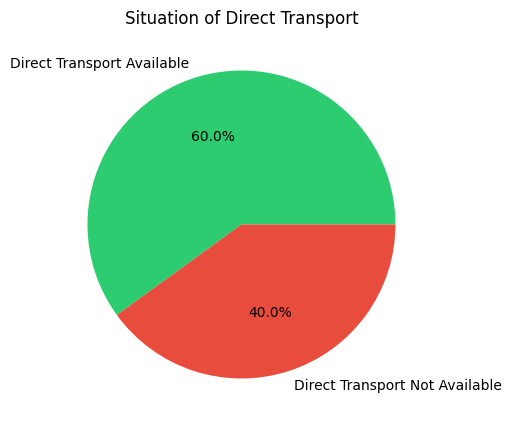

In [ ]:
import matplotlib.pyplot as plt
transport_counts = df['Has_Direct_Transport'].value_counts()
labels = ['Direct Transport Available', 'Direct Transport Not Available']

plt.figure(figsize=(6,6))
plt.pie(transport_counts, labels=labels, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title('Situation of Direct Transport')
plt.show()


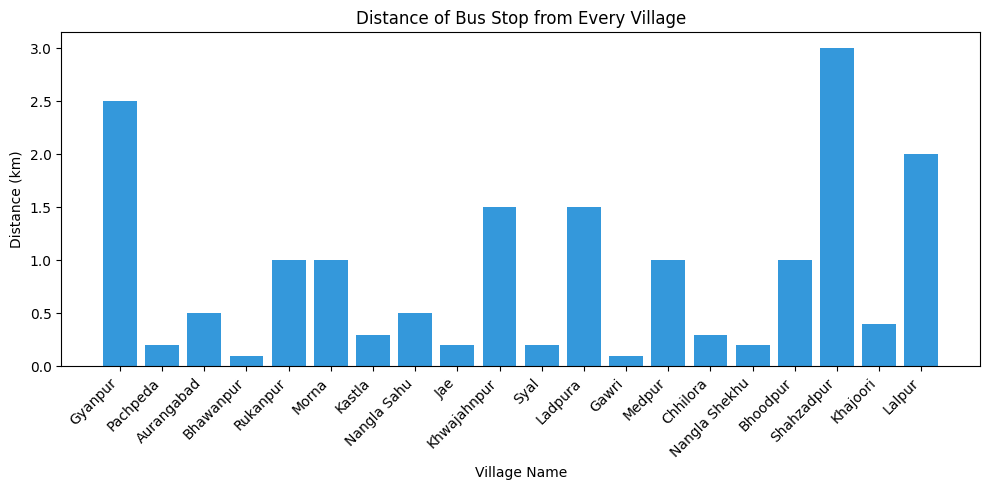

In [15]:
plt.figure(figsize=(10,5))
plt.bar(df['Village_name'], df['Distance_to_Bus_Stop_Km'], color='#3498db')
plt.xticks(rotation=45, ha='right')
plt.title('Distance of Bus Stop from Every Village')
plt.xlabel('Village Name')
plt.ylabel('Distance (km)')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features aur Target alag karo
X = df[['Population', 'Distance_to_Bus_Stop_Km', 'Distance_to_Meerut', 'Road_Paved']]
y = df['Has_Direct_Transport']

# Train aur Test split karo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 4)
Testing data: (4, 4)


In [18]:
# Model banao aur train karo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction karo
y_pred = model.predict(X_test)

# Accuracy dekho
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [19]:
import pickle

with open('../Model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
